# 01b — Injury Target Table for Modelling

## Goal
Turn the exploratory injury label from **NB01** into the **final target table** for the prediction model:

1. **Finalize the taxonomy** — resolve the ambiguous bucket, lock the keep/exclude decision
2. **One clean row per target injury spell** — deduplicate overlapping episodes
3. **Add prior-injury / recurrence features** — injury history that a model can use

**Output:** `data/transfermarkt/derived/target_injury_spells.csv`  
**Input:** `data/transfermarkt/derived/injury_label_table.csv` (from NB01)

## 1. Setup & Load NB01 Output

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 60)
sns.set_theme(style="whitegrid", palette="muted")

# Repo-relative paths (this notebook lives in notebooks/)
DATA_ROOT = Path("../data/transfermarkt")
DERIVED   = DATA_ROOT / "derived"

# Load the full injury label table produced by NB01
df = pd.read_csv(DERIVED / "injury_label_table.csv", parse_dates=["from_date", "end_date"])
print(f"Loaded injury_label_table: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"\nLabel distribution:")
print(df["label_category"].value_counts())
df.head(3)

Loaded injury_label_table: 143,173 rows × 18 columns

Label distribution:
label_category
exclude      104437
keep          21203
ambiguous     17533
Name: count, dtype: int64


,player_id,player_name,injury_reason,label_category,injury_subtype,from_date,end_date,days_missed,games_missed,season_name,position,main_position,age_at_injury,height,foot,citizenship,market_value_eur,is_time_loss
0,2,Mario Basler (2),Ankle injury,exclude,NaN,1996-06-05,1996-07-01,27.0,1,95/96,Midfield - Right Midfield,Midfield,27.5,186.0,right,Germany,NaN,True
1,2,Mario Basler (2),unknown injury,exclude,NaN,1997-11-23,1997-12-11,19.0,4,97/98,Midfield - Right Midfield,Midfield,28.9,186.0,right,Germany,NaN,True
2,2,Mario Basler (2),unknown injury,exclude,NaN,2000-09-12,2000-10-02,21.0,4,00/01,Midfield - Right Midfield,Midfield,31.7,186.0,right,Germany,NaN,True


## 2. Finalize the Taxonomy

NB01 left **17,533 ambiguous** injuries — mostly "Muscle injury" (6,433), "muscular problems" (4,880), "Torn muscle fiber" (2,662). These *could* be lower-limb soft-tissue, but we have no way to know the body region.

**Decision:** We adopt a **conservative approach** for the primary target table:
- **Keep** → retained as target injuries (hamstring, groin/adductor, calf, thigh)
- **Exclude + Ambiguous** → dropped from the target table

However, ambiguous injuries still matter for **prior-injury features** — a "Muscle injury" 3 weeks before a hamstring tear is relevant context. So we keep them in a side table for feature engineering but not as prediction targets.

We also apply a minimum-severity filter: **only time-loss injuries (days_missed ≥ 1)** count as true injury spells.

In [2]:
# ──────────────────────────────────────────────────────────────
# 2a. Split into target vs. context injuries
# ──────────────────────────────────────────────────────────────

# Target injuries: keep + time-loss
target = df[(df["label_category"] == "keep") & (df["days_missed"] >= 1)].copy()
print(f"Target injuries (keep + time-loss): {len(target):,}")

# Context injuries: ambiguous muscle injuries — useful for prior-injury features
# These are kept in a separate table; they are NOT prediction targets
context_ambiguous = df[df["label_category"] == "ambiguous"].copy()
print(f"Context-only (ambiguous):           {len(context_ambiguous):,}")

# Excluded: everything else
excluded = df[df["label_category"] == "exclude"]
print(f"Excluded:                           {len(excluded):,}")

# Quick sanity: subtype distribution in target
print(f"\nTarget subtype breakdown:")
print(target["injury_subtype"].value_counts())

Target injuries (keep + time-loss): 21,203
Context-only (ambiguous):           17,533
Excluded:                           104,437

Target subtype breakdown:
injury_subtype
hamstring         7730
groin_adductor    6563
calf              3742
thigh             3168
Name: count, dtype: int64


## 3. One Clean Row per Injury Spell

Some players may have **overlapping or back-to-back injury records** for the same body region (e.g., a hamstring strain that gets re-classified mid-recovery). We need to:

1. **Detect overlapping spells** for the same player + body region
2. **Merge them** into a single continuous spell (take the earliest `from_date` and latest `end_date`)
3. Keep only **one row per distinct injury episode**

In [3]:
# ──────────────────────────────────────────────────────────────
# 3a. Detect overlapping spells
# ──────────────────────────────────────────────────────────────

# Sort chronologically within each player + subtype
target = target.sort_values(["player_id", "injury_subtype", "from_date"]).reset_index(drop=True)

# For each row, check if it overlaps with the previous row (same player + subtype)
target["prev_end"] = target.groupby(["player_id", "injury_subtype"])["end_date"].shift(1)
target["overlaps_prev"] = (
    target["prev_end"].notna() & (target["from_date"] <= target["prev_end"])
)

n_overlaps = target["overlaps_prev"].sum()
print(f"Overlapping spells detected: {n_overlaps:,} / {len(target):,} rows")
print(f"({n_overlaps / len(target) * 100:.2f}% of target injuries)")

if n_overlaps > 0:
    print(f"\nSample overlapping rows:")
    overlap_ids = target[target["overlaps_prev"]]["player_id"].unique()[:3]
    for pid in overlap_ids:
        player_rows = target[target["player_id"] == pid][["player_name", "injury_subtype", 
                            "from_date", "end_date", "days_missed", "injury_reason", "overlaps_prev"]]
        print(f"\n  Player {pid}:")
        print(player_rows.to_string(index=False))

Overlapping spells detected: 80 / 21,203 rows
(0.38% of target injuries)

Sample overlapping rows:

  Player 1080:
         player_name injury_subtype  from_date   end_date  days_missed  injury_reason  overlaps_prev
Albert Streit (1080)          thigh 2008-11-21 2008-12-09         19.0 Thigh problems          False
Albert Streit (1080)          thigh 2008-11-27 2008-12-07         11.0 Thigh problems           True

  Player 3224:
             player_name injury_subtype  from_date   end_date  days_missed  injury_reason  overlaps_prev
Jonathan Woodgate (3224)           calf 2011-03-29 2011-04-09         12.0  Calf problems          False
Jonathan Woodgate (3224) groin_adductor 2008-10-26 2008-10-29          4.0 Groin problems          False
Jonathan Woodgate (3224) groin_adductor 2009-08-09 2009-09-09         32.0 Groin problems          False
Jonathan Woodgate (3224) groin_adductor 2009-11-22 2011-02-15        451.0 Groin problems          False
Jonathan Woodgate (3224) groin_adductor 2

In [8]:
# ──────────────────────────────────────────────────────────────
# 3b. Merge overlapping spells into single episodes
# ──────────────────────────────────────────────────────────────

def merge_overlapping_spells(group):
    """Merge overlapping/consecutive injury spells for same player+subtype.
    
    Returns a DataFrame with one row per distinct spell, taking:
    - earliest from_date
    - latest end_date
    - recomputed days_missed
    - summed games_missed
    - first injury_reason (most specific label for that spell)
    """
    group = group.sort_values("from_date").reset_index(drop=True)
    spells = []
    current = group.iloc[0].copy()
    
    for i in range(1, len(group)):
        row = group.iloc[i]
        # If this row overlaps or is contiguous with current spell, merge
        if pd.notna(current["end_date"]) and row["from_date"] <= current["end_date"]:
            # Extend the spell
            if pd.notna(row["end_date"]):
                current["end_date"] = max(current["end_date"], row["end_date"])
            current["days_missed"] = (current["end_date"] - current["from_date"]).days
            current["games_missed"] = current["games_missed"] + row["games_missed"]
        else:
            spells.append(current)
            current = row.copy()
    spells.append(current)
    return pd.DataFrame(spells)


# Apply only if overlaps exist; otherwise skip for efficiency
if n_overlaps > 0:
    # Use include_groups=False to avoid FutureWarning, then re-attach group keys
    merged_parts = []
    for (pid, subtype), grp in target.groupby(["player_id", "injury_subtype"]):
        result = merge_overlapping_spells(grp)
        result["player_id"] = pid
        result["injury_subtype"] = subtype
        merged_parts.append(result)
    merged = pd.concat(merged_parts, ignore_index=True)
    
    print(f"Before merge: {len(target):,} rows")
    print(f"After merge:  {len(merged):,} rows")
    print(f"Spells merged: {len(target) - len(merged):,}")
    target_clean = merged.copy()
else:
    print("No overlapping spells — target table is already clean.")
    target_clean = target.copy()

# Drop helper columns
target_clean = target_clean.drop(columns=["prev_end", "overlaps_prev"], errors="ignore")
print(f"\nClean target table: {len(target_clean):,} rows × {target_clean.shape[1]} columns")
print(f"Columns: {target_clean.columns.tolist()}")

Before merge: 21,203 rows
After merge:  21,123 rows
Spells merged: 80

Clean target table: 21,123 rows × 18 columns
Columns: ['player_id', 'player_name', 'injury_reason', 'label_category', 'injury_subtype', 'from_date', 'end_date', 'days_missed', 'games_missed', 'season_name', 'position', 'main_position', 'age_at_injury', 'height', 'foot', 'citizenship', 'market_value_eur', 'is_time_loss']


## 4. Prior-Injury & Recurrence Features

For each target injury spell, we compute **backward-looking** features from the player's full injury history (including ambiguous muscle injuries as context):

| Feature | Description |
|---------|-------------|
| `n_prior_total` | Total prior injuries (any type) for this player before this spell |
| `n_prior_same_region` | Prior injuries to the **same body region** (e.g., prior hamstring injuries) |
| `n_prior_target` | Prior target (keep) injuries for this player |
| `days_since_last_injury` | Days between this spell and the player's previous injury (any type) |
| `days_since_last_same_region` | Days between this spell and previous same-region injury |
| `is_recurrence` | Binary: same-region injury within **180 days** of a previous one |
| `career_injury_burden` | Cumulative days missed before this spell |

In [5]:
# ──────────────────────────────────────────────────────────────
# 4a. Build the full injury timeline for feature computation
# ──────────────────────────────────────────────────────────────

# We use ALL injuries (keep + ambiguous) for computing prior-injury features.
# Excluded injuries (illness, fractures, etc.) are NOT counted as muscle injury history.
history = df[df["label_category"].isin(["keep", "ambiguous"])].copy()
history = history.sort_values(["player_id", "from_date"]).reset_index(drop=True)

# Map ambiguous injuries to a generic "unknown_muscle" subtype for region tracking
history["injury_subtype"] = history["injury_subtype"].fillna("unknown_muscle")

print(f"Injury history for feature engineering: {len(history):,} rows")
print(f"  keep:      {(history['label_category'] == 'keep').sum():,}")
print(f"  ambiguous: {(history['label_category'] == 'ambiguous').sum():,}")
print(f"\nSubtype distribution in history:")
print(history["injury_subtype"].value_counts())

Injury history for feature engineering: 38,736 rows
  keep:      21,203
  ambiguous: 17,533

Subtype distribution in history:
injury_subtype
unknown_muscle    17533
hamstring          7730
groin_adductor     6563
calf               3742
thigh              3168
Name: count, dtype: int64


In [9]:
# ──────────────────────────────────────────────────────────────
# 4b. Compute prior-injury features for each target spell
# ──────────────────────────────────────────────────────────────

RECURRENCE_WINDOW_DAYS = 180  # same-region injury within 6 months = recurrence

def compute_prior_features(target_df, history_df):
    """For each row in target_df, compute backward-looking injury history features."""
    
    # Pre-index history by player for fast lookup
    history_by_player = history_df.groupby("player_id")
    
    n_prior_total = []
    n_prior_same_region = []
    n_prior_target = []
    days_since_last = []
    days_since_last_same = []
    is_recurrence = []
    career_burden = []
    
    for _, row in target_df.iterrows():
        pid = row["player_id"]
        inj_date = row["from_date"]
        region = row["injury_subtype"]
        
        # Get this player's history before this injury
        if pid in history_by_player.groups:
            player_hist = history_by_player.get_group(pid)
            prior = player_hist[player_hist["from_date"] < inj_date]
        else:
            prior = pd.DataFrame()
        
        # n_prior_total: all prior injuries (keep + ambiguous)
        n_total = len(prior)
        n_prior_total.append(n_total)
        
        # n_prior_same_region: prior injuries to the same body region
        prior_same = prior[prior["injury_subtype"] == region]
        n_same = len(prior_same)
        n_prior_same_region.append(n_same)
        
        # n_prior_target: prior "keep" injuries only
        n_tgt = (prior["label_category"] == "keep").sum()
        n_prior_target.append(n_tgt)
        
        # days_since_last_injury
        if n_total > 0:
            last_date = prior["from_date"].max()
            days_since_last.append((inj_date - last_date).days)
        else:
            days_since_last.append(np.nan)
        
        # days_since_last_same_region
        if n_same > 0:
            last_same_date = prior_same["from_date"].max()
            gap = (inj_date - last_same_date).days
            days_since_last_same.append(gap)
            is_recurrence.append(gap <= RECURRENCE_WINDOW_DAYS)
        else:
            days_since_last_same.append(np.nan)
            is_recurrence.append(False)
        
        # career_injury_burden: cumulative days missed before this spell
        burden = prior["days_missed"].sum() if n_total > 0 else 0
        career_burden.append(burden)
    
    target_df = target_df.copy()
    target_df["n_prior_total"] = n_prior_total
    target_df["n_prior_same_region"] = n_prior_same_region
    target_df["n_prior_target"] = n_prior_target
    target_df["days_since_last_injury"] = days_since_last
    target_df["days_since_last_same_region"] = days_since_last_same
    target_df["is_recurrence"] = is_recurrence
    target_df["career_injury_burden_days"] = career_burden
    
    return target_df


print(f"Computing prior-injury features for {len(target_clean):,} target spells...")
target_final = compute_prior_features(target_clean, history)
print("Done.")

Computing prior-injury features for 21,123 target spells...
Done.


In [10]:
# ──────────────────────────────────────────────────────────────
# 4c. Inspect the prior-injury features
# ──────────────────────────────────────────────────────────────

prior_cols = ["n_prior_total", "n_prior_same_region", "n_prior_target",
              "days_since_last_injury", "days_since_last_same_region",
              "is_recurrence", "career_injury_burden_days"]

print("Prior-injury feature statistics:\n")
print(target_final[prior_cols].describe().round(1))

print(f"\n\nRecurrence rate: {target_final['is_recurrence'].mean()*100:.1f}%")
print(f"  ({target_final['is_recurrence'].sum():,} recurrences out of {len(target_final):,} spells)")

# Recurrence rate by subtype
print(f"\nRecurrence rate by injury subtype:")
recur_by_sub = target_final.groupby("injury_subtype")["is_recurrence"].agg(["sum", "count", "mean"])
recur_by_sub.columns = ["recurrences", "total", "rate"]
recur_by_sub["rate"] = (recur_by_sub["rate"] * 100).round(1)
print(recur_by_sub)

Prior-injury feature statistics:

       n_prior_total  n_prior_same_region  n_prior_target  \
count        21123.0              21123.0         21123.0   
mean             1.5                  0.4             1.0   
std              1.9                  0.8             1.4   
min              0.0                  0.0             0.0   
25%              0.0                  0.0             0.0   
50%              1.0                  0.0             0.0   
75%              2.0                  1.0             1.0   
max             13.0                  9.0            13.0   

       days_since_last_injury  days_since_last_same_region  \
count                 12244.0                       5652.0   
mean                    499.9                        586.3   
std                     609.2                        692.0   
min                       1.0                          3.0   
25%                      99.0                         97.0   
50%                     271.0               

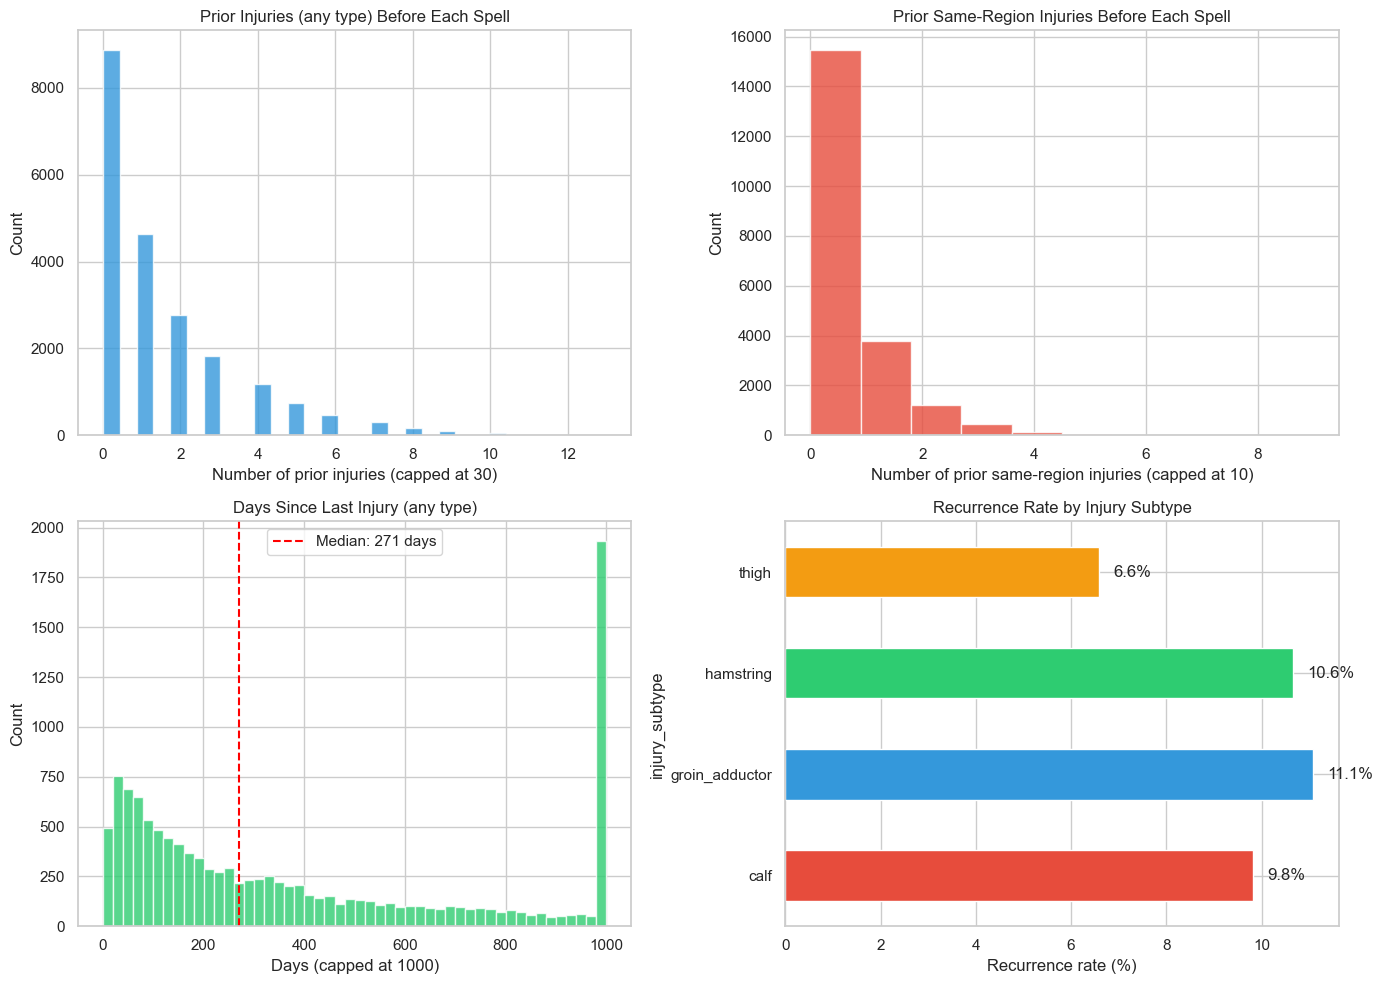

In [11]:
# ──────────────────────────────────────────────────────────────
# 4d. Visualize prior-injury distributions
# ──────────────────────────────────────────────────────────────

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Top-left: distribution of n_prior_total
axes[0, 0].hist(target_final["n_prior_total"].clip(upper=30), bins=30,
                color="#3498db", edgecolor="white", alpha=0.8)
axes[0, 0].set_title("Prior Injuries (any type) Before Each Spell")
axes[0, 0].set_xlabel("Number of prior injuries (capped at 30)")
axes[0, 0].set_ylabel("Count")

# Top-right: distribution of n_prior_same_region
axes[0, 1].hist(target_final["n_prior_same_region"].clip(upper=10), bins=10,
                color="#e74c3c", edgecolor="white", alpha=0.8)
axes[0, 1].set_title("Prior Same-Region Injuries Before Each Spell")
axes[0, 1].set_xlabel("Number of prior same-region injuries (capped at 10)")
axes[0, 1].set_ylabel("Count")

# Bottom-left: days_since_last_injury distribution
valid_gap = target_final["days_since_last_injury"].dropna()
axes[1, 0].hist(valid_gap.clip(upper=1000), bins=50,
                color="#2ecc71", edgecolor="white", alpha=0.8)
axes[1, 0].axvline(x=valid_gap.median(), color="red", linestyle="--",
                    label=f"Median: {valid_gap.median():.0f} days")
axes[1, 0].set_title("Days Since Last Injury (any type)")
axes[1, 0].set_xlabel("Days (capped at 1000)")
axes[1, 0].set_ylabel("Count")
axes[1, 0].legend()

# Bottom-right: recurrence rate by subtype
recur_plot = target_final.groupby("injury_subtype")["is_recurrence"].mean() * 100
recur_plot.plot.barh(ax=axes[1, 1], color=["#e74c3c", "#3498db", "#2ecc71", "#f39c12"])
axes[1, 1].set_title("Recurrence Rate by Injury Subtype")
axes[1, 1].set_xlabel("Recurrence rate (%)")
for i, v in enumerate(recur_plot.values):
    axes[1, 1].text(v + 0.3, i, f"{v:.1f}%", va="center")

plt.tight_layout()
plt.show()

## 5. Export the Final Target Table

In [12]:
# ──────────────────────────────────────────────────────────────
# 5a. Select final columns and export
# ──────────────────────────────────────────────────────────────

final_cols = [
    # Identifiers
    "player_id", "player_name",
    # Injury spell
    "injury_reason", "injury_subtype",
    "from_date", "end_date", "days_missed", "games_missed",
    "season_name",
    # Player context
    "position", "main_position", "age_at_injury",
    "height", "foot", "citizenship",
    "market_value_eur",
    # Prior-injury features
    "n_prior_total", "n_prior_same_region", "n_prior_target",
    "days_since_last_injury", "days_since_last_same_region",
    "is_recurrence", "career_injury_burden_days",
]

target_export = target_final[final_cols].copy()
target_export = target_export.sort_values(["player_id", "from_date"]).reset_index(drop=True)

# Save
out_path = DERIVED / "target_injury_spells.csv"
target_export.to_csv(out_path, index=False)
print(f"✓ Saved → {out_path}")
print(f"  {target_export.shape[0]:,} rows × {target_export.shape[1]} columns")

# Show schema
print(f"\nFinal column list:")
for c in target_export.columns:
    print(f"  {c:<30s}  {target_export[c].dtype}")

✓ Saved → ..\data\transfermarkt\derived\target_injury_spells.csv
  21,123 rows × 23 columns

Final column list:
  player_id                       int64
  player_name                     object
  injury_reason                   str
  injury_subtype                  str
  from_date                       datetime64[us]
  end_date                        datetime64[us]
  days_missed                     float64
  games_missed                    int64
  season_name                     str
  position                        str
  main_position                   str
  age_at_injury                   float64
  height                          float64
  foot                            object
  citizenship                     str
  market_value_eur                float64
  n_prior_total                   int64
  n_prior_same_region             int64
  n_prior_target                  int64
  days_since_last_injury          float64
  days_since_last_same_region     float64
  is_recurrence             

In [13]:
# ──────────────────────────────────────────────────────────────
# 5b. Final summary dashboard
# ──────────────────────────────────────────────────────────────

print("=" * 65)
print("NOTEBOOK 01b — TARGET INJURY SPELLS: FINAL SUMMARY")
print("=" * 65)

print(f"\n{'DATASET':─^65}")
print(f"  Target injury spells:         {len(target_export):>10,}")
print(f"  Unique players:               {target_export['player_id'].nunique():>10,}")
print(f"  Date range:                   {target_export['from_date'].min().date()} → {target_export['from_date'].max().date()}")

print(f"\n{'SUBTYPES':─^65}")
for sub in ["hamstring", "groin_adductor", "calf", "thigh"]:
    n = (target_export["injury_subtype"] == sub).sum()
    pct = n / len(target_export) * 100
    med = target_export.loc[target_export["injury_subtype"] == sub, "days_missed"].median()
    print(f"  {sub:<18s}: {n:>6,} ({pct:4.1f}%)  median {med:.0f}d missed")

print(f"\n{'RECURRENCE':─^65}")
print(f"  Recurrence rate (≤180d same region): {target_export['is_recurrence'].mean()*100:.1f}%")
print(f"  Median prior injuries per spell:     {target_export['n_prior_total'].median():.0f}")
print(f"  Median career burden before spell:   {target_export['career_injury_burden_days'].median():.0f} days")

print(f"\n{'COMPLETENESS':─^65}")
print(f"  Has player name:   {target_export['player_name'].notna().mean()*100:.1f}%")
print(f"  Has market value:  {target_export['market_value_eur'].notna().mean()*100:.1f}%")
print(f"  Has age at injury: {target_export['age_at_injury'].notna().mean()*100:.1f}%")

print(f"\n{'OUTPUT':─^65}")
print(f"  {out_path}")
print("\n" + "=" * 65)
print("✓ Target table ready for modelling.")
print("=" * 65)

NOTEBOOK 01b — TARGET INJURY SPELLS: FINAL SUMMARY

─────────────────────────────DATASET─────────────────────────────
  Target injury spells:             21,123
  Unique players:                   11,217
  Date range:                   1974-09-02 → 2025-09-12

────────────────────────────SUBTYPES─────────────────────────────
  hamstring         :  7,710 (36.5%)  median 28d missed
  groin_adductor    :  6,524 (30.9%)  median 24d missed
  calf              :  3,728 (17.6%)  median 22d missed
  thigh             :  3,161 (15.0%)  median 19d missed

───────────────────────────RECURRENCE────────────────────────────
  Recurrence rate (≤180d same region): 10.0%
  Median prior injuries per spell:     1
  Median career burden before spell:   15 days

──────────────────────────COMPLETENESS───────────────────────────
  Has player name:   99.5%
  Has market value:  97.4%
  Has age at injury: 100.0%

─────────────────────────────OUTPUT──────────────────────────────
  ..\data\transfermarkt\derived\t

In [14]:
# Quick peek at the final table
target_export.head(10)

,player_id,player_name,injury_reason,injury_subtype,from_date,end_date,days_missed,games_missed,season_name,position,main_position,age_at_injury,height,foot,citizenship,market_value_eur,n_prior_total,n_prior_same_region,n_prior_target,days_since_last_injury,days_since_last_same_region,is_recurrence,career_injury_burden_days
0,7,Dimitrios Grammozis (7),Calf injury,calf,2002-12-05,2002-12-17,13.0,2,02/03,Midfield - Defensive Midfield,Midfield,24.4,179.0,right,Greece Germany,NaN,0,0,0,NaN,NaN,False,0.0
1,10,Miroslav Klose (10),Hamstring injury,hamstring,2015-08-20,2015-10-08,50.0,10,15/16,Attack - Centre-Forward,Attack,37.2,184.0,right,Germany,1000000.0,2,0,0,501.0,NaN,False,43.0
2,10,Miroslav Klose (10),Thigh problems,thigh,2015-12-18,2015-12-31,14.0,1,15/16,Attack - Centre-Forward,Attack,37.5,184.0,right,Germany,1000000.0,3,0,1,120.0,NaN,False,93.0
3,16,Jörgen Pettersson (16),Hamstring injury,hamstring,2003-07-14,2003-08-15,33.0,6,03/04,Attack - Centre-Forward,Attack,27.8,0.0,NaN,Sweden,NaN,0,0,0,NaN,NaN,False,0.0
4,26,Roman Weidenfeller (26),Adductor pain,groin_adductor,2014-04-17,2014-04-21,5.0,1,13/14,Goalkeeper,Goalkeeper,33.7,190.0,left,Germany,5000000.0,0,0,0,NaN,NaN,False,0.0
5,27,Murat Yakin (27),Calf strain,calf,1999-09-16,1999-09-20,5.0,2,99/00,Defender - Centre-Back,Defender,25.0,186.0,right,Switzerland Türkiye,NaN,0,0,0,NaN,NaN,False,0.0
6,46,Darko Pivaljević (46),Hamstring injury,hamstring,2003-09-14,2003-09-29,16.0,2,03/04,Attack - Centre-Forward,Attack,28.6,0.0,NaN,Serbia,NaN,0,0,0,NaN,NaN,False,0.0
7,46,Darko Pivaljević (46),Adductor injury,groin_adductor,2005-02-14,2005-04-03,49.0,5,04/05,Attack - Centre-Forward,Attack,30.0,0.0,NaN,Serbia,850000.0,1,0,1,519.0,NaN,False,16.0
8,63,Michael Ballack (63),Calf problems,calf,2006-06-03,2006-06-09,7.0,1,05/06,Midfield - Central Midfield,Midfield,29.7,0.0,NaN,Germany,35000000.0,0,0,0,NaN,NaN,False,0.0
9,63,Michael Ballack (63),Calf problems,calf,2009-09-25,2009-10-04,10.0,3,09/10,Midfield - Central Midfield,Midfield,33.0,0.0,NaN,Germany,22000000.0,1,1,1,1210.0,1210.0,False,7.0
